# 04-2 분포 요약하기

데이터를 숫자로 요약하면 다른 데이터와 비교하기는 좋지만, 한눈에 파악하기는 조금 어렵습니다.

그래프는 이런 점에서 매우 유용한 도구입니다.

이번 절에서는 전체 데이터 분포를 살펴보고 통찰을 얻을 수 있는 대표적인 세 가지 그래프를 알아보겠습니다.

또한 각 그래프를 맷플롯립과 판다스로 그리는 방법을 배워보겠습니다.

## 산점도 그리기

In [1]:
import gdown

gdown.download('https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)

Downloading...
From: https://bit.ly/3pK7iuu
To: /content/ns_book7.csv
100%|██████████| 53.8M/53.8M [00:00<00:00, 112MB/s]


'ns_book7.csv'

In [2]:
import pandas as pd

ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


전체 데이터를 한눈에 파악하려면 그래프가 가장 좋은 방법입니다.

데이터를 그림으로 요약할 수 있는 대표적인 그래프인

산점도(scatter plot), 히스토그램(histogram), 상자수염그림(box-and-whisker plot)을 배워 보겠습니다.

##산점도그리기

산점도는 데이터를 화면에 뿌리듯 그리는 그래프입니다.

조금 더 형식적으로 말하면 두 변수(variable)혹은 두 가지 특성(feature)값을 직교 좌표계에 점으로 나타내는 그래프입니다.

그래프를 그리기 위해서는 별도의 패키지가 필요합니다.

파이썬에서 그래프를 그리는 데 사용하는 대표적인 패키지는 맷플롯립(matplotlib)입니다.

파이썬의 다양한 데이터 과학 패키지들도 맷플롯립을 활용할 정도로 널리 사용하므로 구글 코랩에서도 기본 설치되어 있습니다.

##scatter()함수

산점도는 scatter()함수로 그립니다. 함수 첫 번째 매개변수에 4개 포인트의 x축 좌표를 전달하고 두번째 매개변수에 y축 좌표를 전달합니다.

다음처럼 scatter()함수를 호출한 다음에는 show()함수를 호출하여 그래프를 출력합니다.

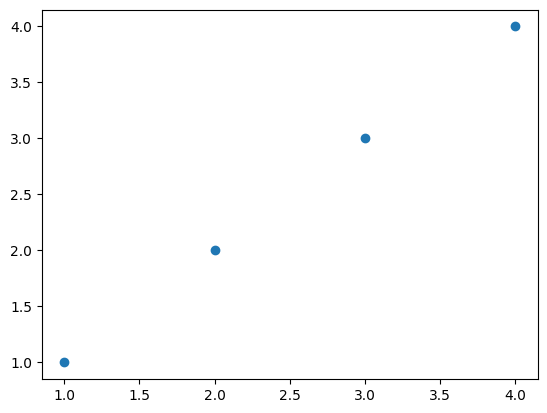

In [3]:
import matplotlib.pyplot as plt

plt.scatter([1,2,3,4], [1,2,3,4])
plt.show()

파이썬 스크립트나 대화형셀(interactive shell)을 사용할 때는 꼭 show()함수를 호출해야 그래프가 그려집니다.

최신 주피터노트북과 코랩에서는 코드 셀이 끝날 때 자동으로 show()함수를 호출해 주기 때문에 명시적으로 이 함수를 호출할 필요가 없지만, 일관성 있는 코드를 위해서 여기서는 show()함수를 사용하겠습니다.

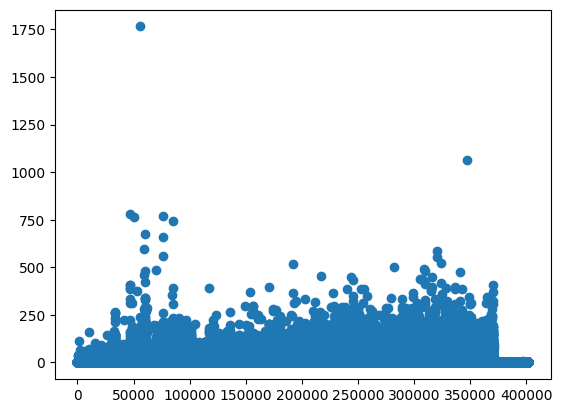

In [4]:
plt.scatter(ns_book7['번호'], ns_book7['대출건수'])
plt.show()

츨력된 그래프를 보면 데이터가 많이 겹쳐져 있는 것을 알 수 있습니다. x축에 놓인 '번호'열의 값을 따라 대출건스가 어떻게 변화하나요?

사실 '번호'열은 원본 대출 데이터에서 각 행에 붙여진 일련번호입니다.

이런 일련번호는 데이터(도서)를 구분하기 위한 용도이므로 특별한 의미를 가지지않습니다.

'번호'열의 값이 낮거나 높다는 대출 건수가 달라지지 않을 가능성이 높죠.

따라서 위에 출력된 산점도에서 이런 경향을 잘 볼 수 있습니다.

대출건수(y축의 값)는 번호(x축의 값)를 따라 비교적 고르게 퍼져있습니다.

그럼'번호'열 말고 '도서권수'와'대출건수'열의 산점도를 살펴보자.

이전과 마찬가지로 scatter()함수의 첫 번째 매개변수에는 x축에 해당하는 '도서권수'열을 지정하고, 두 번째 매개변수에는 y축에 해당하는 '대출건수'열을 지정합니다.

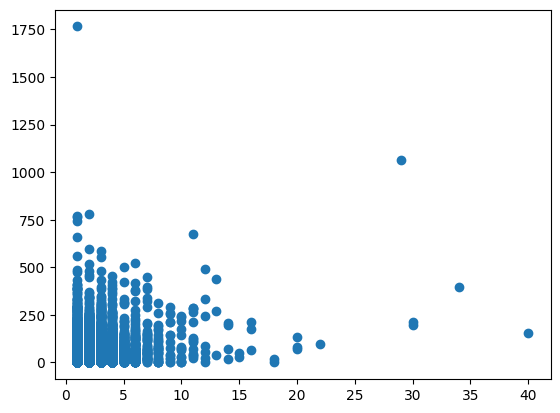

In [5]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'])
plt.show()

도서권수가 많으면 대출건수도 많을 것이라 예상하기 쉽지만, 앞의 산점도를 보면 이런 경향을 파악하기 쉽지 않습니다.

특히 대부분의 도서가 1 ~ 2권이기 때문에 x축과 0 ~ 10범위인 왼쪽 아래 모서리부분에 같은 값을 가진 데이터 포인트가 중첩되어 그려지네요.

이럴때는 단점도에 투명도를 주면 중첩된 데이터 포인트를 가늠하기 좋습니다.

##투명도조절하기

맷플롯립은 alpha매개변수에 0~1사이의 값으로 투명도를 지정할 수 있습니다.

투명도를 주더라도 데이터가 많이 중첩된 부분은 짙게 나타납니다.

이 매개면수를 0.1로 지정하여 산점도를 다시 그려보죠!

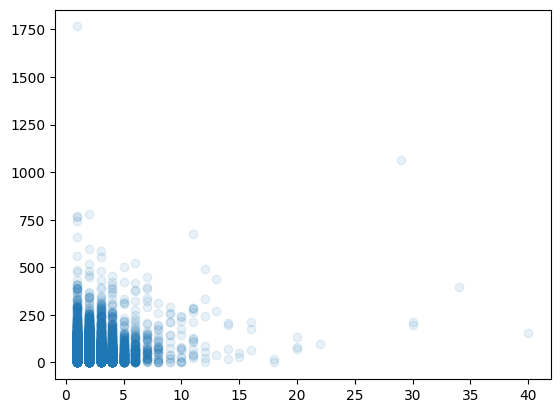

In [6]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

예상대로 왼쪽 모서리 아래 근처에 중첩된 데이터포인트가 많습니다. 투명도르 더 낮추더라도 왼쪽 모서리 아래 근처는 여전히 짙게 나타나는데, 이는 대부분의 도서권수가 적다는 것을 의미합니다.

예전 describe()메서드로 기술통계를 확인했을 때 도서권수의 백분위90%에 위치한 값은 2였습니다.

대부분의 도서권수가 2보다 작다는 것을 알 수 있습니다.



---



도서권수가 대부분 작은 값이기 때문에 도서권수와 대출건수 사이의 관계를 파악하기 어렵습니다.

여기서 도서권수와 대출건수 사이의 관계란 도서권수가 많으면 대출건수도 많다던가, 도서권수가 적을수록 대출건수가 많다는 식입니다.

이러면 전자는 **양의 상관관계**, 후자는 **음의 상관관계**가 있다고 말합니다.

이번에는 '도서권수'열 대신에 '대출건수'열을 '도서권수'열로 나눈 값을 사용해보죠.

도서권수당 대출건수를 x축에 두고 대출건수를 y축에 놓습니다.

눈썰미가 있는 학생이라면 두 값은 양의 상관관계를 가질 것이라고 예상할 수 있을 겁니다.

대출건수가 높다면 도서권수 당 대출건수도 당연히 높겠죠. 직접한번 확인해보겠습니다.

'대출건수'열을 '도서권수'열로 나눈 값을 average_borrows변수에 저장하고, 이 변수와 '대출건수'열을 차례대로 scatter()함수에 전달합니다.

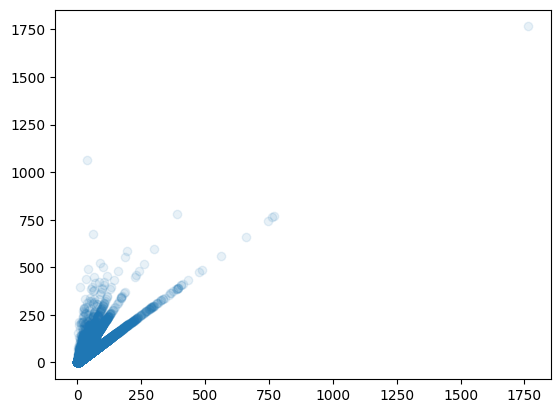

In [ ]:
average_borrows = ns_book7['대출건수']/ns_book7['도서권수']
plt.scatter(average_borrows, ns_book7['대출건수'], alpha=0.1)
plt.show()

출력된 그래프를 보면 x축(도서권수 당 대출건수)이 증가함에 따라 y축(대출건수)이 증가하는 것을 뚜렷하게 볼 수 있습니다.

두 특성사이에는 '양의 상관관계'가 있다고 말할 수 있습니다.

## 히스토그램 그리기
: 수치형 특성의 값을 일정한 구간(bin)으로 나누어 구간 안에 포함된 데이터 개수를 막대 그래프로 표현


 도수(frequency) - 구간 안에 속한 데이터 개수
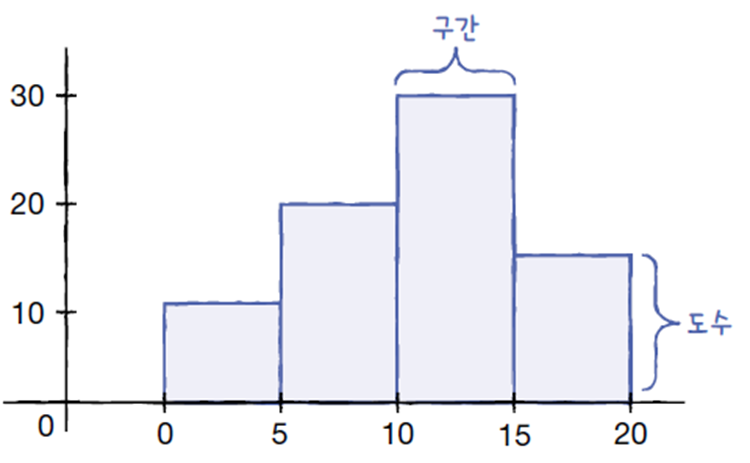

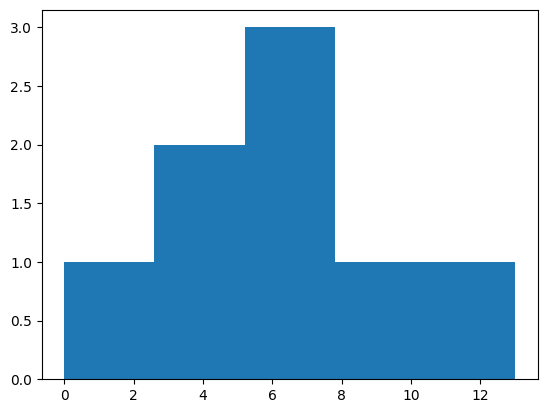

In [ ]:
plt.hist([0,3,5,6,7,7,9,13], bins=5)
plt.show()

어느 구간에 데이터가 많은지 한눈에 보이지만, 구간이 어떻게 나누어졌는지 수치를 확인할 수 없네요.

히스토그램의 구간을 정확하게 확인하기 위해 넘파이에서 제공하는 histogram_bin_edges()함수를 사용해 보겠습니다.

다음처럼 위해서와 동일한 데이터를 전달하여 다섯 구간의 경곗값을 출력해보죠.

In [ ]:
import numpy as np

np.histogram_bin_edges([0,3,5,6,7,7,9,13], bins=5)

array([ 0. ,  2.6,  5.2,  7.8, 10.4, 13. ])

이제 더 많은 데이터를 가상으로 만들어 히스토그램을 그려보겠습니다.

넘파이의 randn()함수는 표준정규분포를 따르는 랜덤한 실수를 생성할 수 있습니다.

이 함수에 샘플 개수를 전달하여 난수(random number)를 생성해 보겠습니다.

In [ ]:
np.random.seed(42)
random_samples = np.random.randn(1000)

위 코드는 랜덤한 실수를 1,000개 생성합니다.

seed()함수를 사용하면 유사난수를 생성할 수 있습니다. 즉 가짜 난수입니다.

In [ ]:
print(np.mean(random_samples), np.std(random_samples))

0.01933205582232549 0.9787262077473543


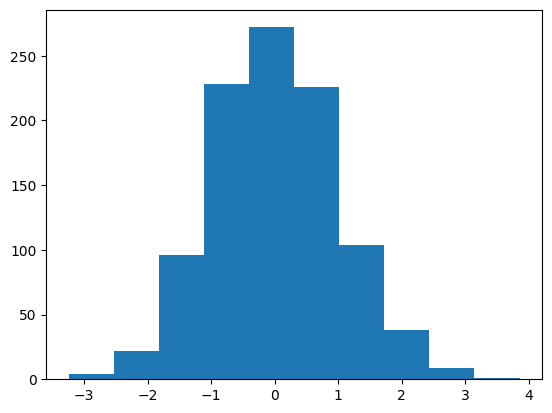

In [ ]:
plt.hist(random_samples)
plt.show()

이제 그럼!! 남산도서관 대출 데이터에서 수치 데이터의 분포를 확인하기 위해 히스토그램을 그려보죠. 먼저 '대출건수'열의 히스토그램을 다음처럼 그릴 수 있습니다.

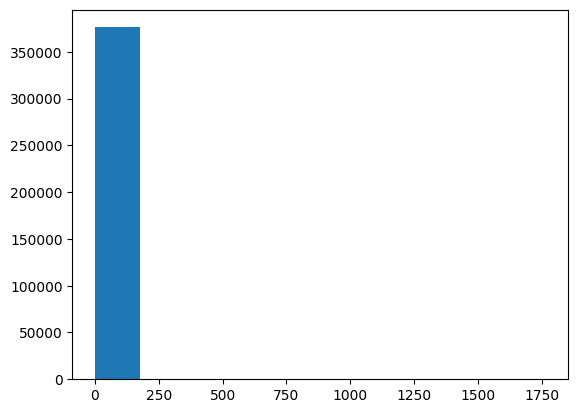

In [ ]:
plt.hist(ns_book7['대출건수'])
plt.show()

산점도에서 보았듯이 대부분 도서의 대출건수는 작습니다.
describe()메서드로 확인한 '대출건수'열의 90%백분위에 해당하는 값은 28에 불과했습니다.

따라서 앞의 그림과 같이 첫 번째 구간의 도수가 너무 커서 다른 구간에는 도수 값이 표시되지 않는 현상이 발생합니다.

##구간조정하기
한 구간의 도수가 너무 커서 다른 구간에는 도수가 표시되지 않는 현상이 발생
y축을 로그스케일(log scale)로 바꾸어 해결

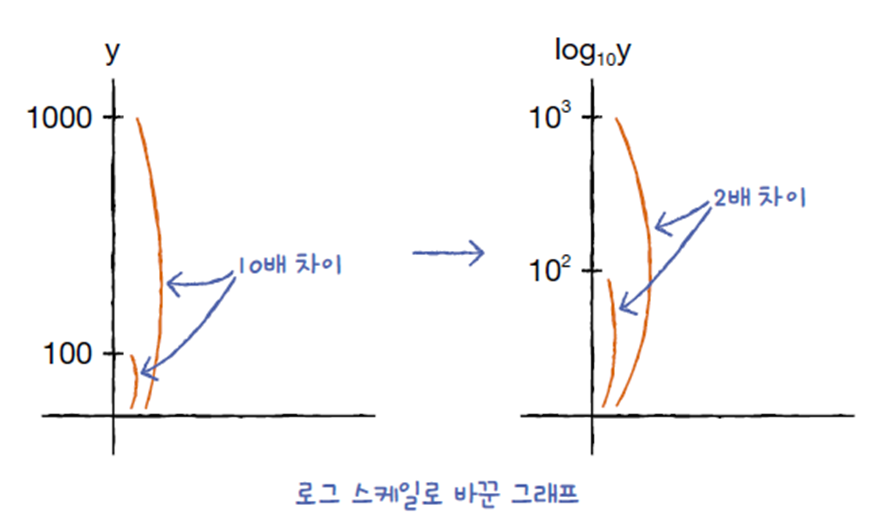

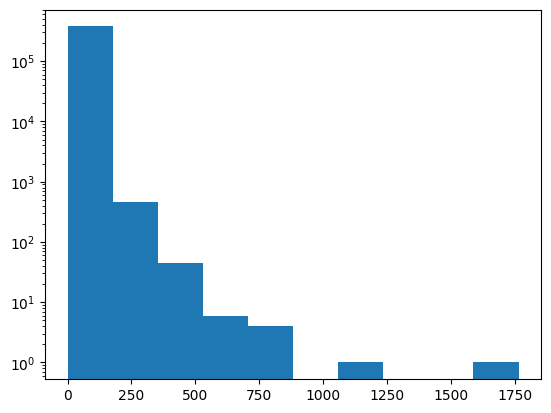

In [ ]:
plt.hist(ns_book7['대출건수'])
plt.yscale('log')
plt.show()

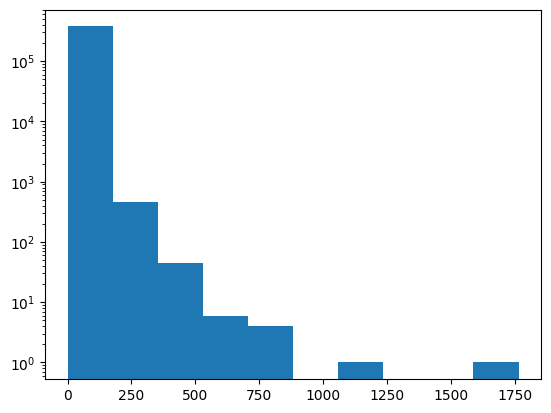

In [ ]:
plt.hist(ns_book7['대출건수'], log=True)
plt.show()

맷플롯립은 기본적으로 밑이 10인 로그 함수를 사용합니다.

그래서 y축의 눈금스케일이 10의 0승에서 10의 5승까지 나타나 있습니다.
눈금을 읽을 때는 지수 부분을 고래혀서 읽으면 됩니다.

이번에는 x축의 구간을 더 세세하게 나누어 볼까요? hist()함수는 기본 10개의 구간을 사용

bins매개변수에서 이를 1000으로 바꾸면 데이터분포를 조금 더 세밀하게 관찰할 수 있습니다.

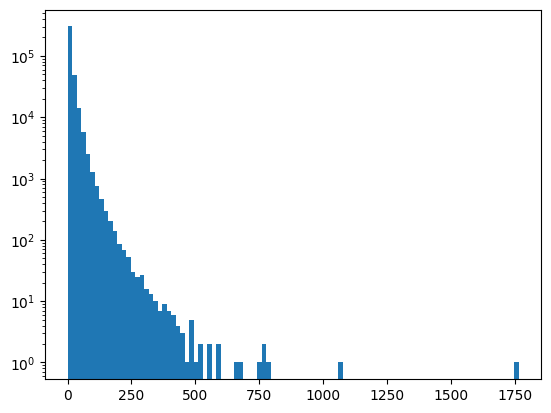

In [ ]:
plt.hist(ns_book7['대출건수'], bins=100)
plt.yscale('log')
plt.show()

확실히 대출건수가0이 가장 많고 대출건수가 증가함에 따라 도수가 줄어듭니다.

이런 그래프는 정규분포와는 거리가 머네요.

이번에는 조금 다른 데이터의 히스토그램을 그려보죠!

도서명의 길이는 정규분표에 가까울까요?

아니면 왼쪽 또는 오른쪽에 편중된 그래프가 그려질까요?

직접 그려보겠습니다.

다음처럼 '도서명'열에 apply()메서드를 사용하여 파이썬의 len()함수를 적용하면 title_len변수는 각 도서명의 길이가 저장된 판다스 시리즈 객체가 됩니다.

이를 1000개의 구간을 가진 히스토그램으로 그려보겠습니다.

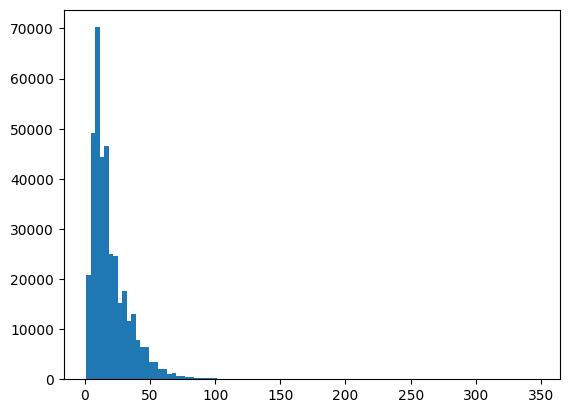

In [ ]:
title_len = ns_book7['도서명'].apply(len)
plt.hist(title_len, bins=100)
plt.show()

대출건수만큼은 아니지만 왼쪽에 편중된 그래프입니다.
x축에 데이터가 골고루 그려지도록 바꿀 수 있을까요?

앞에서 y축에 로그스케일을 적용했던 것처럼 x축에도 로그스케일을 적용할 수 있습니다.

이렇게 하면 x축을 따라 작은 값과 큰 값의 차이가 줄어들 것입니다.

y축에 로그스케일을 적용하는 ysclae()함수와 비슷하게 xscale()함수를 사용하면 됩니다.

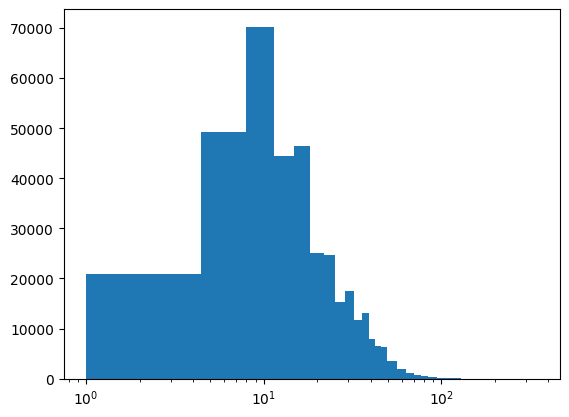

In [ ]:
plt.hist(title_len, bins=100)
plt.xscale('log')
plt.show()

## 상자 수염 그림 그리기
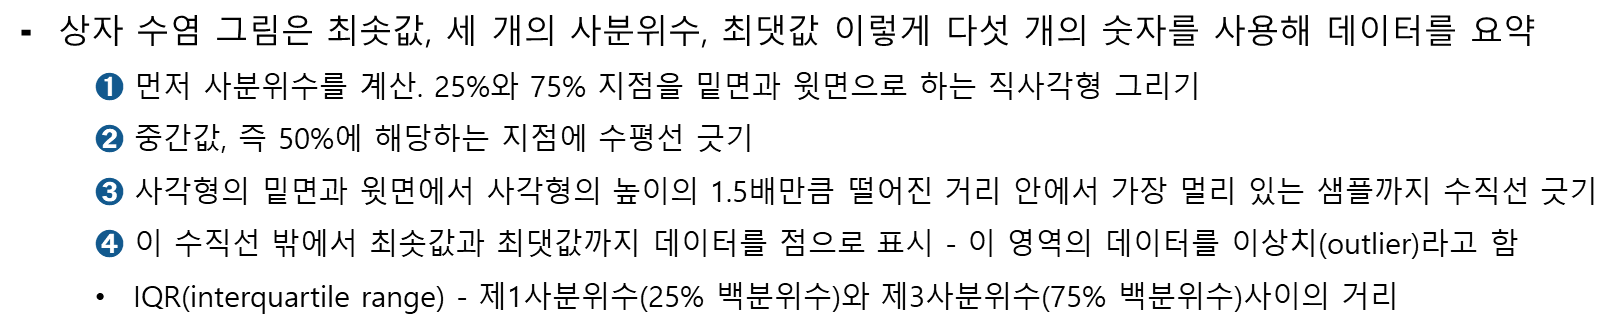
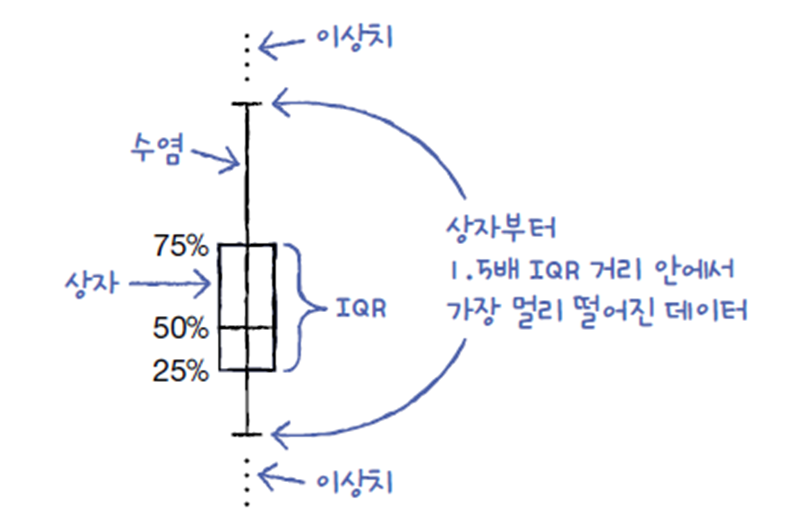

상자 수염 그림은 여러 개의 특성을 시각적으로 비교하기 좋습니다.

특히 데이터가 어떤 방향으로 더 많이 늘어져 있는지 한눈에 파악할 수 있죠!

**이상치 값을 무조건적으로 제거하는 것은 아닙니다!!!**
데이터 과학이나 머신러닝에서 관측 범위에서 아주 많이 벗어난 값 혹은 데이터에 내제한 패턴을 크게 벗어난 값을 이상치라고 합니다.

이상치는 머신러닝 모델에 큰 영향을 미칠 수도 있기 때문에 모델을 훈련하기 전에 삭제할 수 있습니다. 하지만 상자 수염 그림에 나오는 이상치는 단순히 IQR의 1.5배 거리 밖의 데이터를 의미하며, 데이터 분석에서의 이상치는 데이터양이 많을 수록 영향이 줄기 때문에 반드시 제거해야 하는 것은 아닙니다.

##boxplot()함수

In [ ]:
temp = ns_book7[['대출건수','도서권수']]

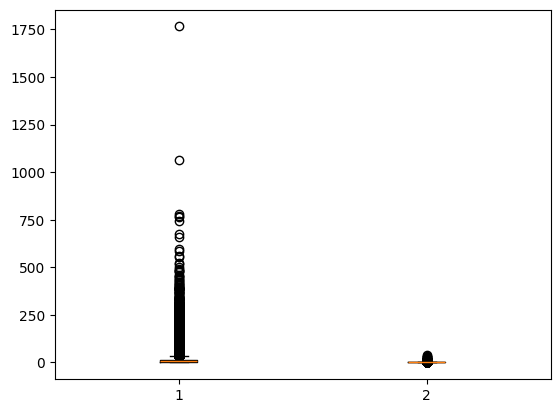

In [ ]:
plt.boxplot(temp)
plt.show()

1번 상자(대출건수)와 2번 상자(도서권수)데이터는 사분위수가 매우 작아서 직사각형 상자가 거의 보이질 않습니다. 중간에 붉은 수평선으로 표시됩니다.

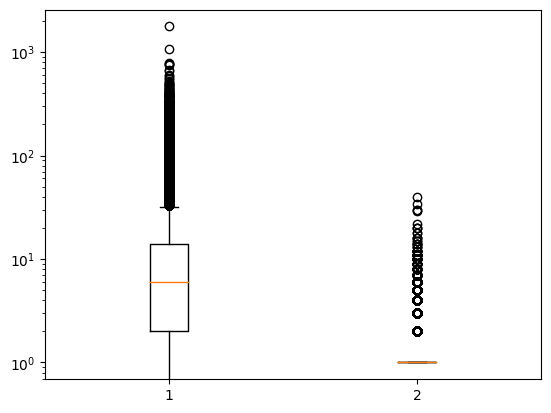

In [ ]:
plt.boxplot(ns_book7[['대출건수','도서권수']])
plt.yscale('log')
plt.show()

y축을 로그 스케일로 바꾸어도 2번 상자(도서권수)는 여전히 보이지 않지만, 1번 상자(대출건수)는 상자 모양을 뚜렷하게 확인할 수 있습니다.

사실 '도서권수'열의 사분위수는 모두 1이기 때문에 상자가 보이자않는 것이 맞습니다.

##상자수염그림 수평으로 그리기

이따금 여러 개의 상자 수염 그림을 수평으로 그려야 할 때가 있습니다.

그럴때는 boxplot()함수의 vert매개변수를 기본값 True에서 False로 바꾸면 됩니다.

x-y축이 바뀌므로 로그 스케일도 x축에 지정해야 합니다.

히스토그램과 마찬가지로 xscale()함수를 사용합니다.

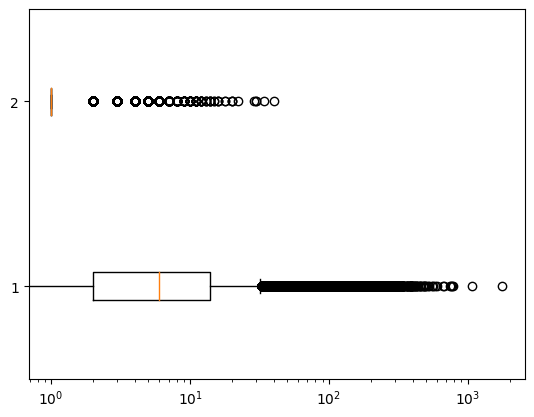

In [ ]:
plt.boxplot(ns_book7[['대출건수','도서권수']], vert=False)
plt.xscale('log')
plt.show()

##수염 길이 조정하기

기본적으로 수염의 길이는 IQR의 1.5배입니다.

하지만 더 길게 혹은 더 짧게 나타낼 수도 있습니다.

boxplot()함수의 whis매개변수에서 이를 조정할 수 있습니다.

기본값 1.5를 10으로 바꾸어서 IQR의 10배 범위 안에서 가장 멀리 떨어진 데이터까지 수업을 그려보겠습니다.

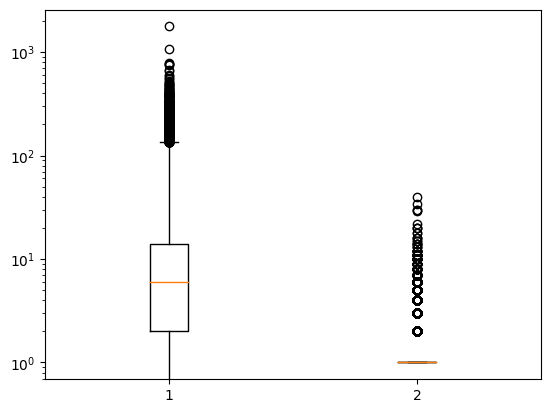

In [ ]:
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=10)
plt.yscale('log')
plt.show()

전의 그래프와 비교하면 1번상자(대출건수)의 수염이 확실히 길어진 것을 확인할 수 있습니다.

2번상자(도서권수)의 IQR은 0이기 때문에 여전히 수염이 전혀 그려지지 않습니다.

whis매개변수는 백분율로도 지정할 수 있습니다.

예를 들어 (10,90)으로 지정하면 10%, 90%백분위수에 해당하는 데이터까지 수염을 그립니다.

다음처럼 (0,100)으로 지정하면 마지막 데이터까지 수염을 그릴 수 있습니다.

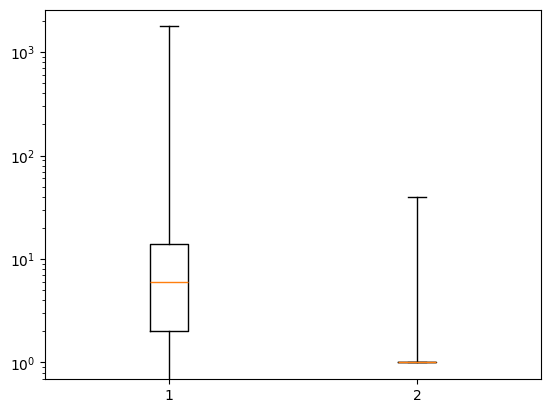

In [ ]:
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=(0,100))
plt.yscale('log')
plt.show()

## 판다스의 그래프 함수

판다스 데이터프레임에도 여러가지 그래프를 그릴 수 있는 메서드를 제공

### 산점도 그리기

판다스 데이터프레임 객체의 plot속성은 여러가지 그래프를 그릴 수 있는 메서드를 제공합니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44428 (\N{HANGUL SYLLABLE GWEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

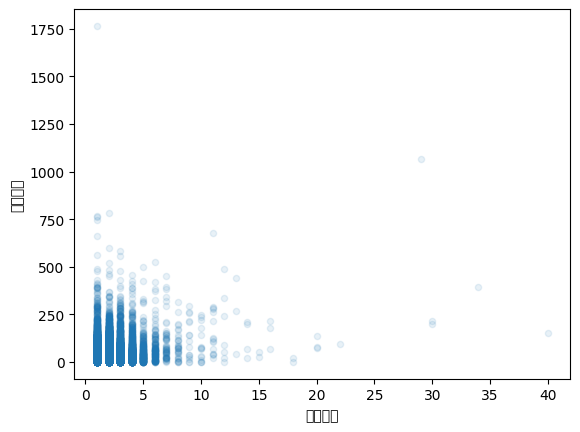

In [ ]:
ns_book7.plot.scatter('도서권수', '대출건수', alpha=0.1)
plt.show()

### 히스토그램 그리기

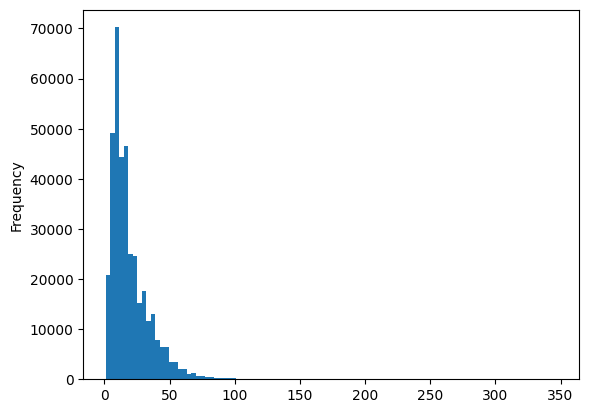

In [ ]:
ns_book7['도서명'].apply(len).plot.hist(bins=100)
plt.show()

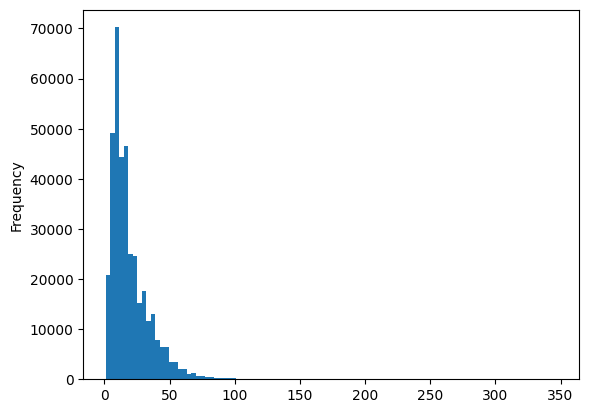

In [ ]:
ns_book7['도서명'].apply(len).plot.hist(bins=100)
plt.show()

### 상자 수염 그림 그리기

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

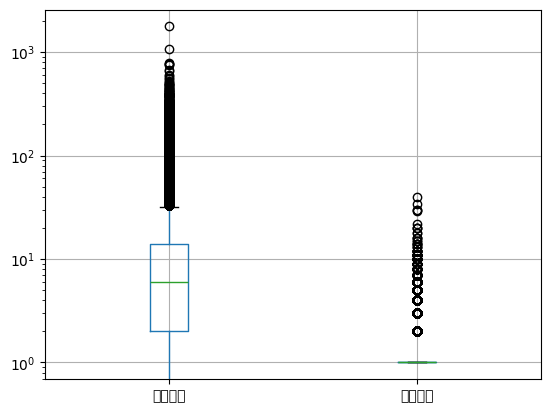

In [ ]:
ns_book7[['대출건수','도서권수']].boxplot()
plt.yscale('log')
plt.show()